In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
# Load Medical Insurance dataset
df = pd.read_csv('Medical_insurance.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# Categorial label encoding for sex (female=0, male=1), smoker (no=0, yes=1), region (one-hot)
df['sex'] = (df['sex'] == 'male').astype(int)
df['smoker'] = (df['smoker'] == 'yes').astype(int)
df = pd.get_dummies(df, columns=['region'], prefix='region')
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [4]:
# Split features and target, then train/test (90/10)
train_df = df.sample(frac=0.9, random_state=42)
test_df = df.drop(train_df.index)

train_features = train_df.drop(columns=['charges'])
test_features = test_df.drop(columns=['charges'])
train_labels = train_df['charges'].copy()
test_labels = test_df['charges'].copy()

print("Train size:", len(train_features), "Test size:", len(test_features))
print("Feature columns:", list(train_features.columns))

Train size: 2495 Test size: 277
Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [5]:
# Normalize single feature (age)
age_normalizer = layers.Normalization(input_shape=[1,], axis=None)
age_normalizer.adapt(np.array(train_features['age']))

# Normalize all features (multiple linear regression and DNN)
normalizer = layers.Normalization(axis=-1)
train_features_numeric = np.array(train_features, dtype=np.float32)
normalizer.adapt(train_features_numeric)
print("Normalization layers adapted on training data.")

c:\Users\nguye\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Normalization layers adapted on training data.


In [6]:
linear_one_model = keras.Sequential([
    age_normalizer,
    layers.Dense(units=1)
])
linear_one_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)
linear_one_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [7]:
history = linear_one_model.fit(
    train_features['age'],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)
test_results = {}
test_results['1-feature linear regression'] = linear_one_model.evaluate(
    test_features['age'], test_labels, verbose=0
)
print("MAE (1-feature linear regression):", test_results['1-feature linear regression'])

MAE (1-feature linear regression): 13542.2265625


In [8]:
linear_multi_model = keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])
linear_multi_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)
history = linear_multi_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)
test_results['Multiple linear regression'] = linear_multi_model.evaluate(
    test_features, test_labels, verbose=0
)
print("MAE (multiple linear regression):", test_results['Multiple linear regression'])

MAE (multiple linear regression): 13534.798828125


In [9]:
def build_dnn(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(loss='mean_absolute_error', optimizer=keras.optimizers.Adam(0.001))
    return model

dnn_one_model = build_dnn(age_normalizer)
dnn_one_model.fit(
    train_features['age'],
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)
test_results['1-feature DNN'] = dnn_one_model.evaluate(
    test_features['age'], test_labels, verbose=0
)
print("MAE (1-feature DNN):", test_results['1-feature DNN'])

MAE (1-feature DNN): 7558.48779296875


In [10]:
dnn_multi_model = build_dnn(normalizer)
dnn_multi_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)
test_results['multiple-feature DNN'] = dnn_multi_model.evaluate(
    test_features, test_labels, verbose=0
)
print("MAE (multiple-feature DNN):", test_results['multiple-feature DNN'])

MAE (multiple-feature DNN): 2467.58984375


In [12]:
mae_df = pd.DataFrame(list(test_results.items()), columns=['Model', 'MAE'])
mae_df = mae_df.sort_values('MAE').reset_index(drop=True)
print(mae_df.to_string(index=False))
best_model_name = mae_df.loc[0, 'Model']
print(f"\nBest-performing model: {best_model_name}")

                      Model          MAE
       multiple-feature DNN  2467.589844
              1-feature DNN  7558.487793
 Multiple linear regression 13534.798828
1-feature linear regression 13542.226562

Best-performing model: multiple-feature DNN


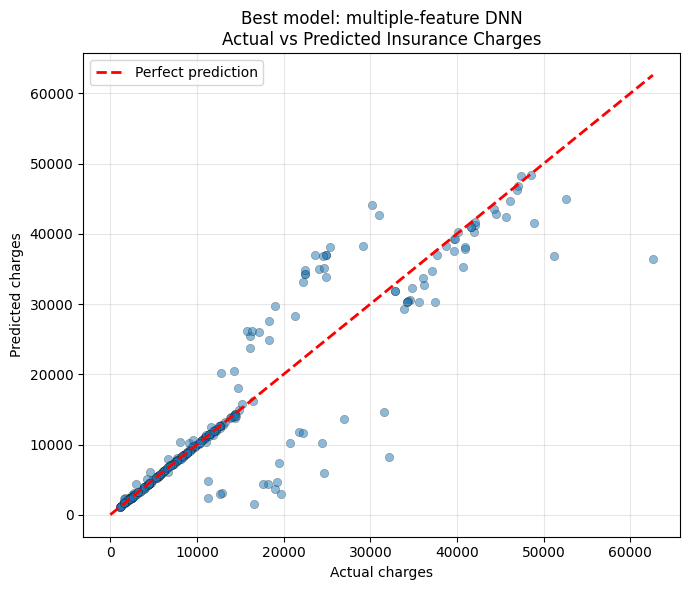

In [13]:
# Select best model and get predictions
model_map = {
    '1-feature linear regression': (linear_one_model, test_features['age']),
    'Multiple linear regression': (linear_multi_model, test_features),
    '1-feature DNN': (dnn_one_model, test_features['age']),
    'multiple-feature DNN': (dnn_multi_model, test_features)
}
best_model, best_X = model_map[best_model_name]
y_pred = best_model.predict(best_X, verbose=0).flatten()

# Actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(test_labels, y_pred, alpha=0.5, edgecolors='k', linewidth=0.3)
max_val = max(test_labels.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.title(f'Best model: {best_model_name}\nActual vs Predicted Insurance Charges')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()